# Add a beam to a solved cavity

In this tutorial we solve a pillbox cavity without a beam and find its TM010 mode and
R/Q. Then we add a beam to the solved project: only the beam's own columns are
computed, the port results stay as they are. Near the resonance the beam impedance has
a pole whose strength is R/Q; we read R/Q from it and compare with the eigenmode's.

**Prerequisites:** [Compute a beam impedance](collimator_impedance.ipynb) and
[Find resonances and look at fields](../basics/resonances_and_fields.ipynb).

## 1. Solve the cavity without a beam

### 1.1 Build and mesh the pillbox

A pillbox of radius 100 mm and length 100 mm, with a beam pipe of radius 30 mm and
length 100 mm on each side (dimensions in millimetres). There is no beam yet, so we ask
for curve order 4 ourselves: the beam comes later, on this mesh.

In [1]:
from cavsim3d.core.em_project import EMProject

proj = EMProject(name="pillbox_beam", base_dir="./simulations", overwrite=True)
proj.create_primitive("pillbox", name="cavity", n_cells=1,
                      dims=[100, 100, 30, 0, 100], beampipe="both")
proj.generate_mesh(maxh=0.015, curve_order=4)

✅ Creating new project 'pillbox_beam' at simulations\pillbox_beam


### 1.2 Run the sweep

In [2]:
cfg = dict(fmin=1.0, fmax=1.3, nsamples=4, nportmodes=3, order=3)
res = proj.fds.solve(**cfg)


Structure Topology
  Type: Single structure
  Domains (1): ['vacuum']
  Ports (2): ['port1', 'port2']
  Mesh elements: 3658



Assembling Matrices...


Solving port eigenmodes...


Calculating Port Eigenmodes...


	port1 mode 0: TE_11 (cos), kc=61.3728, sigma=+1
	port1 mode 1: TE_11 (sin), kc=61.3728, sigma=+1


	port1 mode 2: TM_01, kc=80.1608, sigma=+1
	port2 mode 0: TE_11 (cos), kc=61.3728, sigma=+1
	port2 mode 1: TE_11 (sin), kc=61.3728, sigma=+1
	port2 mode 2: TM_01, kc=80.1608, sigma=+1
Port eigenmodes complete: 6 total modes



FDS Solve: 1.0000 - 1.3000 GHz, 4 samples


Global Coupled Solve


  Auto solver: 76452 unknowns, a factorisation needs about 0.4 GB of 33.0 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 5.55s


### 1.3 Find TM010 and its R/Q

In [3]:
fom = proj.fds.fom
f0 = fom.get_resonant_frequencies(n_modes=1)[0]
rq = fom.get_rq(0)["RQ"]
print(f"TM010: f0 = {f0 / 1e9:.5f} GHz, R/Q = {rq:.2f} Ohm")

TM010: f0 = 1.16485 GHz, R/Q = 162.56 Ohm


TM010 resonates at 1.165 GHz with R/Q = 162.56 Ω, computed from the mode's field:
the voltage it gives a charge passing on the axis, squared, over its stored energy.
(This cell takes a minute: it solves the eigenproblem of the full-order model.)

## 2. Add the beam

### 2.1 Keep the port results to compare

We copy $S_{21}$ before the beam is added.

In [4]:
import numpy as np

s21_before = np.array(proj.fds.fom.S_dict["1(1)2(1)"])

### 2.2 Add a beam on the axis and solve again

In [5]:
proj.add_beam("beam")
res = proj.fds.solve(**cfg)

✅ Beam added to solved port results: solving the beam columns only (the port results are kept).


  Auto solver: 76452 unknowns, a factorisation needs about 0.4 GB of 32.8 GB free -> 'direct'


  Beam columns: 5.20s


The request is the same as before, so the solve keeps the stored port results and
computes only the beam's columns: the log says *Beam added to solved port results:
solving the beam columns only*. This takes a few seconds: it still factorises the
system matrix at each frequency, but solves only the beam's right-hand side there.

### 2.3 Check the port results

In [6]:
s21_after = np.array(proj.fds.fom.S_dict["1(1)2(1)"])
print("S21 unchanged:", np.array_equal(s21_before, s21_after))
print("S~ columns:", proj.fds.fom.tilde_labels[1])

S21 unchanged: True
S~ columns: ['1(1)', '1(2)', '1(3)', '2(1)', '2(2)', '2(3)', 'b(1)']


The port results are the same, bit for bit, and $\tilde{S}$ has the beam `b(1)` after
the six port modes.

## 3. Read R/Q from the beam impedance

`beam_impedance()` reads the beam impedance with every port mode matched: the waves the
beam excites leave through the ports without reflection. `beam_impedance(ports="open")`
reads it with every port mode open-circuited instead: no current in any port mode, so
for the port modes each port face is a magnetic wall, as in the eigenproblem of
section 1.3. The beam still passes through the faces; only the waves it excites are
reflected there.

Below the cut-off of the beam pipes, with the ports open, a lossless mode is a pole of
the beam impedance:
$Z_\parallel(\omega) \approx j\,\frac{R}{Q}\,\frac{\omega_0}{4(\omega_0 - \omega)}$.

### 3.1 Sweep around the resonance

Twelve frequencies within ±3 % of $f_0$; $f_0$ itself is not among them.

In [7]:
res = proj.fds.solve(**dict(cfg, fmin=0.97 * f0 / 1e9, fmax=1.03 * f0 / 1e9, nsamples=12))
f = proj.fds.fom.frequencies
z_open = proj.fds.fom.beam_impedance(ports="open")


FDS Solve: 1.1299 - 1.1998 GHz, 12 samples


Global Coupled Solve


  Auto solver: 76452 unknowns, a factorisation needs about 0.4 GB of 32.8 GB free -> 'direct'


  
Coupled solve complete: 2 external ports in 18.28s


### 3.2 Compare with the pole of the eigenmode

The pole with the eigenmode's $f_0$ and R/Q, drawn on a fine grid (and left out right
at $f_0$, where it is infinite), against the computed beam impedance.

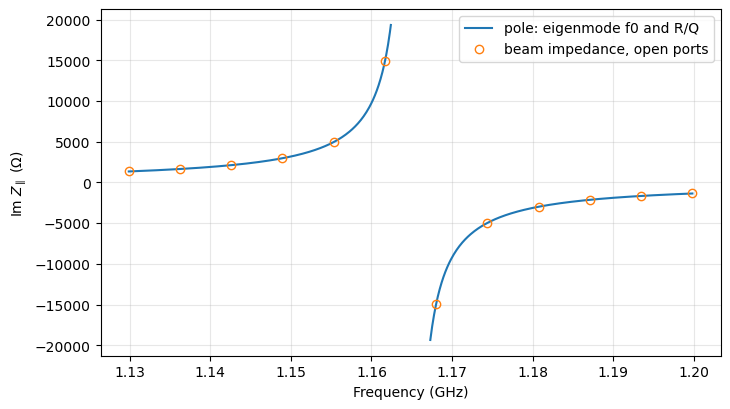

In [8]:
import matplotlib.pyplot as plt

f_line = np.linspace(f[0], f[-1], 601)
w0 = 2 * np.pi * f0
z_pole = rq * w0 / (4 * (w0 - 2 * np.pi * f_line))     # Im Z_par of the pole
z_pole[np.abs(z_pole) > 2e4] = np.nan

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(f_line / 1e9, z_pole, label="pole: eigenmode f0 and R/Q")
ax.plot(f / 1e9, z_open.imag, lw=0, marker="o", mfc="none", label="beam impedance, open ports")
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel(r"Im $Z_\parallel$ ($\Omega$)")
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

### 3.3 Read R/Q at each frequency

Solving the pole formula for R/Q at each frequency gives R/Q from the beam impedance
alone.

In [9]:
w = 2 * np.pi * f
rq_beam = (z_open * 4 * (w0 - w) / (1j * w0)).real
for fk, r in zip(f, rq_beam):
    print(f"f/f0 - 1 = {fk / f0 - 1:+.4f}:  R/Q = {r:7.2f} Ohm")
print(f"eigenmode: R/Q = {rq:.2f} Ohm")

f/f0 - 1 = -0.0300:  R/Q =  163.44 Ohm
f/f0 - 1 = -0.0245:  R/Q =  163.31 Ohm
f/f0 - 1 = -0.0191:  R/Q =  163.17 Ohm
f/f0 - 1 = -0.0136:  R/Q =  163.02 Ohm
f/f0 - 1 = -0.0082:  R/Q =  162.84 Ohm
f/f0 - 1 = -0.0027:  R/Q =  162.66 Ohm
f/f0 - 1 = +0.0027:  R/Q =  162.46 Ohm
f/f0 - 1 = +0.0082:  R/Q =  162.24 Ohm
f/f0 - 1 = +0.0136:  R/Q =  162.01 Ohm
f/f0 - 1 = +0.0191:  R/Q =  161.76 Ohm
f/f0 - 1 = +0.0245:  R/Q =  161.50 Ohm
f/f0 - 1 = +0.0300:  R/Q =  161.22 Ohm
eigenmode: R/Q = 162.56 Ohm


At the two frequencies closest to $f_0$ (0.27 % on either side), the beam impedance
gives R/Q = 162.66 and 162.46 Ω, around the eigenmode's 162.56 Ω. Further from the
resonance the other modes add their share, and R/Q read this way drifts, by 0.8 % at
3 % from $f_0$.

## What we did

We solved a pillbox without a beam, found TM010 and its R/Q, added a beam to the solved
project (only its columns were computed), and read R/Q from the pole of the beam
impedance: two independent routes to the same number.

**Next:** [Beam past a lossy absorber](lossy_absorber.ipynb).

**Background:** [Beam excitation](../../theory/beam.md), §9.7 for the beam impedance
with open ports.